In [3]:
import pandas as pd
import numpy as np

# Load datasets
patients = pd.read_csv("patients.csv")
admissions = pd.read_csv("admissions.csv")
doctors = pd.read_csv("doctors.csv")
treatments = pd.read_csv("treatments.csv")
vitals = pd.read_csv("vitals.csv")


In [4]:
datasets = {
    "Patients": patients,
    "Admissions": admissions,
    "Doctors": doctors,
    "Treatments": treatments,
    "Vitals": vitals
}

overview = []

for name, df in datasets.items():
    overview.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Column Names": ", ".join(df.columns)
    })

overview_df = pd.DataFrame(overview)

display(overview_df)

,Dataset,Rows,Columns,Column Names
0,Patients,1690,8,"patient_id, first_name, last_name, dob, gender..."
1,Admissions,3324,7,"admission_id, patient_id, admission_date, disc..."
2,Doctors,40,5,"doctor_id, first_name, last_name, specializati..."
3,Treatments,8329,6,"treatment_id, admission_id, treatment_date, pr..."
4,Vitals,33148,7,"vital_id, admission_id, recorded_time, heart_r..."


In [5]:
for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    display(df.head())


Patients


,patient_id,first_name,last_name,dob,gender,contact_no,address,chronic_conditions
0,1001,Stephen,Kerr,1976-12-15,Female,1562097834,"84518 Jacob Knoll South Casey, WY 54234",Diabetes
1,1002,Jessica,Guzman,1964-06-11,Female,5669436555,"849 Deleon Island New Reginald, MS 05381",Asthma
2,1003,Gary,Lewis,1939-09-03,Female,7199424360,"7876 Kimberly Burg Reedton, AK 55417",NaN
3,1004,Michelle,Cox,1947-12-09,Female,1876539109,"1886 Alex Track Port James, GU 54638",NaN
4,1005,Vincent,Patel,1947-06-25,Male,3161728431,"143 Williams Forges Apt. 955 Alexanderburgh, M...",Asthma



Admissions


,admission_id,patient_id,admission_date,discharge_date,diagnosis,doctor_id,room_no
0,2001,1001,2026-02-07,2026-02-13,Diabetes Complication,317,R418
1,2002,1001,2026-03-07,2026-03-17,Heart Failure,320,R396
2,2003,1002,2025-05-16,2025-05-21,Asthma Attack,339,R411
3,2004,1003,2025-12-08,2025-12-10,Respiratory Infection,325,R120
4,2005,1003,2025-08-11,2025-08-21,Pneumonia,306,R368



Doctors


,doctor_id,first_name,last_name,specialization,contact_no
0,301,Anthony,Reese,Pulmonologist,5965377606
1,302,Erica,Owens,Pulmonologist,9212316949
2,303,Brittany,Cisneros,Cardiologist,4695711788
3,304,Tracy,James,Neurologist,9451082387
4,305,Mary,Vazquez,Neurologist,8459209544



Treatments


,treatment_id,admission_id,treatment_date,procedure,medication,dosage
0,7001,2001,2025-05-12,IV Fluid Therapy,Atorvastatin,10mg daily
1,7002,2001,2025-12-20,IV Fluid Therapy,Atorvastatin,50mg daily
2,7003,2001,2025-07-28,IV Fluid Therapy,Atorvastatin,25mg daily
3,7004,2001,2025-07-06,IV Fluid Therapy,Atorvastatin,50mg daily
4,7005,2002,2026-02-07,ECG Monitoring,Aspirin,25mg daily



Vitals


,vital_id,admission_id,recorded_time,heart_rate,blood_pressure,oxygen_level,temperature
0,5001,2001,2026-03-06 20:06:42,120,129/81,94,99.94
1,5002,2001,2026-03-02 18:52:52,118,130/71,96,97.13
2,5003,2001,2026-02-10 11:50:10,65,134/73,91,100.22
3,5004,2001,2026-01-05 10:58:43,77,121/70,94,100.48
4,5005,2001,2026-02-18 22:47:00,86,131/85,95,99.80


In [6]:
for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"{name} - Data Types")
    print(f"{'='*60}")
    print(df.dtypes)


Patients - Data Types
patient_id            int64
first_name              str
last_name               str
dob                     str
gender                  str
contact_no            int64
address                 str
chronic_conditions      str
dtype: object

Admissions - Data Types
admission_id      int64
patient_id        int64
admission_date      str
discharge_date      str
diagnosis           str
doctor_id         int64
room_no             str
dtype: object

Doctors - Data Types
doctor_id         int64
first_name          str
last_name           str
specialization      str
contact_no        int64
dtype: object

Treatments - Data Types
treatment_id      int64
admission_id      int64
treatment_date      str
procedure           str
medication          str
dosage              str
dtype: object

Vitals - Data Types
vital_id            int64
admission_id        int64
recorded_time         str
heart_rate          int64
blood_pressure        str
oxygen_level        int64
temperature     

In [7]:
# Missing values
# Missing value analysis

missing_summary = []

for name, df in datasets.items():
    for column in df.columns:
        missing_count = df[column].isna().sum()
        missing_percent = (missing_count / len(df)) * 100
        
        missing_summary.append({
            "Dataset": name,
            "Column": column,
            "Missing Count": missing_count,
            "Missing %": round(missing_percent, 2)
        })

missing_df = pd.DataFrame(missing_summary)

display(
    missing_df[missing_df["Missing Count"] > 0]
    .sort_values(["Dataset", "Missing Count"], ascending=[True, False])
)

,Dataset,Column,Missing Count,Missing %
7,Patients,chronic_conditions,240,14.2


In [8]:
# Exact duplicate rows
# Exact duplicate row analysis

duplicate_summary = []

for name, df in datasets.items():
    duplicate_count = df.duplicated().sum()
    
    duplicate_summary.append({
        "Dataset": name,
        "Total Rows": len(df),
        "Duplicate Rows": duplicate_count
    })

duplicates_df = pd.DataFrame(duplicate_summary)

display(duplicates_df)

,Dataset,Total Rows,Duplicate Rows
0,Patients,1690,0
1,Admissions,3324,0
2,Doctors,40,0
3,Treatments,8329,0
4,Vitals,33148,0


In [9]:
# Primary-key validation
# Primary key validation

primary_keys = {
    "Patients": "patient_id",
    "Admissions": "admission_id",
    "Doctors": "doctor_id",
    "Treatments": "treatment_id",
    "Vitals": "vital_id"
}

pk_summary = []

for name, key in primary_keys.items():
    df = datasets[name]
    
    pk_summary.append({
        "Dataset": name,
        "Primary Key": key,
        "Rows": len(df),
        "Null Keys": df[key].isna().sum(),
        "Unique Keys": df[key].nunique(),
        "Duplicate Keys": df[key].duplicated().sum()
    })

pk_df = pd.DataFrame(pk_summary)

display(pk_df)

,Dataset,Primary Key,Rows,Null Keys,Unique Keys,Duplicate Keys
0,Patients,patient_id,1690,0,1690,0
1,Admissions,admission_id,3324,0,3324,0
2,Doctors,doctor_id,40,0,40,0
3,Treatments,treatment_id,8329,0,8329,0
4,Vitals,vital_id,33148,0,33148,0


In [10]:
# Converting dates temporarily for validation
# Create temporary datetime conversions for validation

patients["dob_dt"] = pd.to_datetime(patients["dob"], errors="coerce")

admissions["admission_date_dt"] = pd.to_datetime(
    admissions["admission_date"], errors="coerce"
)

admissions["discharge_date_dt"] = pd.to_datetime(
    admissions["discharge_date"], errors="coerce"
)

treatments["treatment_date_dt"] = pd.to_datetime(
    treatments["treatment_date"], errors="coerce"
)

vitals["recorded_time_dt"] = pd.to_datetime(
    vitals["recorded_time"], errors="coerce"
)

print("Temporary date conversion completed.")

Temporary date conversion completed.


In [11]:
# Check invalid/unparseable dates
date_validation = pd.DataFrame({
    "Dataset": [
        "Patients",
        "Admissions - Admission Date",
        "Admissions - Discharge Date",
        "Treatments",
        "Vitals"
    ],
    "Total Rows": [
        len(patients),
        len(admissions),
        len(admissions),
        len(treatments),
        len(vitals)
    ],
    "Invalid Dates": [
        patients["dob_dt"].isna().sum(),
        admissions["admission_date_dt"].isna().sum(),
        admissions["discharge_date_dt"].isna().sum(),
        treatments["treatment_date_dt"].isna().sum(),
        vitals["recorded_time_dt"].isna().sum()
    ]
})

display(date_validation)

,Dataset,Total Rows,Invalid Dates
0,Patients,1690,0
1,Admissions - Admission Date,3324,0
2,Admissions - Discharge Date,3324,0
3,Treatments,8329,0
4,Vitals,33148,0


In [12]:
# Check admission/discharge logic
invalid_discharge = admissions[
    admissions["discharge_date_dt"].notna() &
    (admissions["discharge_date_dt"] < admissions["admission_date_dt"])
]

print("Admissions with discharge before admission:",
      len(invalid_discharge))

display(
    invalid_discharge[
        [
            "admission_id",
            "patient_id",
            "admission_date",
            "discharge_date",
            "diagnosis"
        ]
    ].head(20)
)

Admissions with discharge before admission: 0


,admission_id,patient_id,admission_date,discharge_date,diagnosis


In [13]:
# Check treatment dates against admissions
treatment_check = treatments.merge(
    admissions[
        [
            "admission_id",
            "admission_date_dt",
            "discharge_date_dt"
        ]
    ],
    on="admission_id",
    how="left"
)

outside_treatment_period = treatment_check[
    (treatment_check["treatment_date_dt"] < treatment_check["admission_date_dt"]) |
    (
        treatment_check["discharge_date_dt"].notna() &
        (treatment_check["treatment_date_dt"] > treatment_check["discharge_date_dt"])
    )
]

print(
    "Treatments outside admission-discharge period:",
    len(outside_treatment_period)
)

display(
    outside_treatment_period[
        [
            "treatment_id",
            "admission_id",
            "treatment_date",
            "admission_date_dt",
            "discharge_date_dt",
            "procedure",
            "medication"
        ]
    ].head(20)
)

Treatments outside admission-discharge period: 8168


,treatment_id,admission_id,treatment_date,admission_date_dt,discharge_date_dt,procedure,medication
0,7001,2001,2025-05-12,2026-02-07,2026-02-13,IV Fluid Therapy,Atorvastatin
1,7002,2001,2025-12-20,2026-02-07,2026-02-13,IV Fluid Therapy,Atorvastatin
2,7003,2001,2025-07-28,2026-02-07,2026-02-13,IV Fluid Therapy,Atorvastatin
3,7004,2001,2025-07-06,2026-02-07,2026-02-13,IV Fluid Therapy,Atorvastatin
4,7005,2002,2026-02-07,2026-03-07,2026-03-17,ECG Monitoring,Aspirin
5,7006,2003,2025-10-04,2025-05-16,2025-05-21,Nebulization,Salbutamol
6,7007,2003,2025-12-21,2025-05-16,2025-05-21,Nebulization,Salbutamol
7,7008,2003,2025-04-21,2025-05-16,2025-05-21,Nebulization,Salbutamol
8,7009,2003,2025-06-17,2025-05-16,2025-05-21,Nebulization,Salbutamol
9,7010,2004,2026-01-13,2025-12-08,2025-12-10,Oxygen Therapy,Amoxicillin


In [14]:
# Check vitals against admissions
vital_check = vitals.merge(
    admissions[
        [
            "admission_id",
            "admission_date_dt",
            "discharge_date_dt"
        ]
    ],
    on="admission_id",
    how="left"
)

outside_vital_period = vital_check[
    (vital_check["recorded_time_dt"].dt.date <
     vital_check["admission_date_dt"].dt.date) |
    (
        vital_check["discharge_date_dt"].notna() &
        (vital_check["recorded_time_dt"].dt.date >
         vital_check["discharge_date_dt"].dt.date)
    )
]

print(
    "Vitals outside admission-discharge period:",
    len(outside_vital_period)
)

display(
    outside_vital_period[
        [
            "vital_id",
            "admission_id",
            "recorded_time",
            "admission_date_dt",
            "discharge_date_dt",
            "heart_rate",
            "oxygen_level",
            "temperature"
        ]
    ].head(20)
)

Vitals outside admission-discharge period: 32501


,vital_id,admission_id,recorded_time,admission_date_dt,discharge_date_dt,heart_rate,oxygen_level,temperature
0,5001,2001,2026-03-06 20:06:42,2026-02-07,2026-02-13,120,94,99.94
1,5002,2001,2026-03-02 18:52:52,2026-02-07,2026-02-13,118,96,97.13
3,5004,2001,2026-01-05 10:58:43,2026-02-07,2026-02-13,77,94,100.48
4,5005,2001,2026-02-18 22:47:00,2026-02-07,2026-02-13,86,95,99.80
5,5006,2001,2026-03-10 20:51:38,2026-02-07,2026-02-13,66,88,97.65
6,5007,2001,2026-01-02 13:43:03,2026-02-07,2026-02-13,107,100,97.61
7,5008,2001,2026-01-25 01:08:00,2026-02-07,2026-02-13,67,91,100.41
8,5009,2001,2026-02-28 11:24:46,2026-02-07,2026-02-13,113,96,100.04
9,5010,2002,2026-01-05 01:39:04,2026-03-07,2026-03-17,69,92,100.85
10,5011,2002,2026-01-30 07:03:17,2026-03-07,2026-03-17,77,91,97.31


# Investigate the Date Pattern

In [15]:
# Check the overall date ranges

print("ADMISSIONS")
print("Admission date range:",
      admissions["admission_date_dt"].min(),
      "to",
      admissions["admission_date_dt"].max())

print("Discharge date range:",
      admissions["discharge_date_dt"].min(),
      "to",
      admissions["discharge_date_dt"].max())

print("\nTREATMENTS")
print("Treatment date range:",
      treatments["treatment_date_dt"].min(),
      "to",
      treatments["treatment_date_dt"].max())

print("\nVITALS")
print("Recorded time range:",
      vitals["recorded_time_dt"].min(),
      "to",
      vitals["recorded_time_dt"].max())

ADMISSIONS
Admission date range: 2025-03-11 00:00:00 to 2026-03-11 00:00:00
Discharge date range: 2025-03-13 00:00:00 to 2026-03-20 00:00:00

TREATMENTS
Treatment date range: 2025-03-11 00:00:00 to 2026-03-11 00:00:00

VITALS
Recorded time range: 2026-01-01 00:02:17 to 2026-03-12 10:43:23


In [16]:
# Compare how many records fall inside vs outside admission periods

print("Treatment records")
print("Inside admission period:",
      len(treatments) - len(outside_treatment_period))
print("Outside admission period:",
      len(outside_treatment_period))

print("\nVital records")
print("Inside admission period:",
      len(vitals) - len(outside_vital_period))
print("Outside admission period:",
      len(outside_vital_period))

Treatment records
Inside admission period: 161
Outside admission period: 8168

Vital records
Inside admission period: 647
Outside admission period: 32501


In [17]:
# Check whether treatment/vital dates appear to be randomly distributed
# across the overall date range

print("\nTreatment dates by year:")
print(treatments["treatment_date_dt"].dt.year.value_counts().sort_index())

print("\nVital dates by year:")
print(vitals["recorded_time_dt"].dt.year.value_counts().sort_index())


Treatment dates by year:
treatment_date_dt
2025    6753
2026    1576
Name: count, dtype: int64

Vital dates by year:
recorded_time_dt
2026    33148
Name: count, dtype: int64


# Foreign-Key Validation

In [18]:
# Validate foreign-key relationships

patient_ids = set(patients["patient_id"])
doctor_ids = set(doctors["doctor_id"])
admission_ids = set(admissions["admission_id"])

invalid_admission_patients = admissions[
    ~admissions["patient_id"].isin(patient_ids)
]

invalid_admission_doctors = admissions[
    ~admissions["doctor_id"].isin(doctor_ids)
]

invalid_treatment_admissions = treatments[
    ~treatments["admission_id"].isin(admission_ids)
]

invalid_vital_admissions = vitals[
    ~vitals["admission_id"].isin(admission_ids)
]

print("Admissions with invalid patient_id:",
      len(invalid_admission_patients))

print("Admissions with invalid doctor_id:",
      len(invalid_admission_doctors))

print("Treatments with invalid admission_id:",
      len(invalid_treatment_admissions))

print("Vitals with invalid admission_id:",
      len(invalid_vital_admissions))

Admissions with invalid patient_id: 0
Admissions with invalid doctor_id: 0
Treatments with invalid admission_id: 0
Vitals with invalid admission_id: 0


In [19]:
# Display examples only if invalid relationships exist

if len(invalid_admission_patients) > 0:
    display(invalid_admission_patients.head())

if len(invalid_admission_doctors) > 0:
    display(invalid_admission_doctors.head())

if len(invalid_treatment_admissions) > 0:
    display(invalid_treatment_admissions.head())

if len(invalid_vital_admissions) > 0:
    display(invalid_vital_admissions.head())

# Investigate chronic_conditions

In [20]:
# Analyze chronic_conditions distribution

print("Missing chronic_conditions:",
      patients["chronic_conditions"].isna().sum())

print("\nChronic conditions distribution:")
display(
    patients["chronic_conditions"]
    .value_counts(dropna=False)
)

Missing chronic_conditions: 240

Chronic conditions distribution:


chronic_conditions
Heart Disease     254
Kidney Disease    253
Asthma            251
NaN               240
Diabetes          236
Hypertension      233
COPD              223
Name: count, dtype: int64

In [21]:
# Check whether missing chronic conditions are concentrated
# in any gender group

display(
    patients.groupby(
        patients["chronic_conditions"].isna()
    )["gender"]
    .value_counts()
)

chronic_conditions  gender
False               Female    764
                    Male      686
True                Female    122
                    Male      118
Name: count, dtype: int64

In [22]:
# Inspect patients with missing chronic conditions

missing_conditions = patients[
    patients["chronic_conditions"].isna()
]

display(
    missing_conditions[
        ["patient_id", "first_name", "last_name", "dob", "gender"]
    ].head(20)
)

,patient_id,first_name,last_name,dob,gender
2,1003,Gary,Lewis,1939-09-03,Female
3,1004,Michelle,Cox,1947-12-09,Female
5,1006,Mallory,Hawkins,1987-04-16,Female
18,1019,Darius,Villarreal,1992-06-08,Female
20,1021,Donald,Arnold,1979-12-31,Female
25,1026,Daniel,Scott,1947-01-20,Male
29,1030,Laura,Aguilar,1991-02-09,Female
35,1036,Jeffrey,Reyes,1960-11-20,Female
56,1057,John,Conner,1959-02-19,Male
57,1058,Tamara,Higgins,1990-06-23,Male


In [23]:
# Validate vital sign ranges

vital_validation = pd.DataFrame({
    "Measure": [
        "Heart Rate",
        "Oxygen Level",
        "Temperature"
    ],
    "Minimum": [
        vitals["heart_rate"].min(),
        vitals["oxygen_level"].min(),
        vitals["temperature"].min()
    ],
    "Maximum": [
        vitals["heart_rate"].max(),
        vitals["oxygen_level"].max(),
        vitals["temperature"].max()
    ],
    "Missing": [
        vitals["heart_rate"].isna().sum(),
        vitals["oxygen_level"].isna().sum(),
        vitals["temperature"].isna().sum()
    ]
})

display(vital_validation)

,Measure,Minimum,Maximum,Missing
0,Heart Rate,60.0,120.0,0
1,Oxygen Level,88.0,100.0,0
2,Temperature,97.0,101.0,0


In [24]:
# Inspect blood pressure values

print("Unique blood pressure values:",
      vitals["blood_pressure"].nunique())

display(
    vitals["blood_pressure"]
    .value_counts()
    .head(20)
)

Unique blood pressure values: 1066


blood_pressure
123/80    50
138/85    49
142/89    49
115/70    48
139/78    47
141/77    47
121/94    46
130/70    46
145/72    46
133/95    46
133/94    45
127/70    44
127/95    44
140/76    44
113/83    44
123/70    44
125/75    44
112/86    44
133/71    44
121/88    44
Name: count, dtype: int64

In [25]:
# Validate blood pressure format

bp_format_check = vitals[
    ~vitals["blood_pressure"].astype(str).str.match(r"^\d+/\d+$")
]

print("Invalid blood pressure format:",
      len(bp_format_check))

display(
    bp_format_check[["vital_id", "blood_pressure"]].head(20)
)

Invalid blood pressure format: 0


,vital_id,blood_pressure


In [26]:
# Convert date columns to proper datetime types

patients["dob"] = pd.to_datetime(patients["dob"])

admissions["admission_date"] = pd.to_datetime(
    admissions["admission_date"]
)
admissions["discharge_date"] = pd.to_datetime(
    admissions["discharge_date"]
)

treatments["treatment_date"] = pd.to_datetime(
    treatments["treatment_date"]
)

vitals["recorded_time"] = pd.to_datetime(
    vitals["recorded_time"]
)

print("Date columns converted successfully.")

print("\nPatients:")
print(patients.dtypes)

print("\nAdmissions:")
print(admissions.dtypes)

print("\nTreatments:")
print(treatments.dtypes)

print("\nVitals:")
print(vitals.dtypes)

Date columns converted successfully.

Patients:
patient_id                     int64
first_name                       str
last_name                        str
dob                   datetime64[us]
gender                           str
contact_no                     int64
address                          str
chronic_conditions               str
dob_dt                datetime64[us]
dtype: object

Admissions:
admission_id                  int64
patient_id                    int64
admission_date       datetime64[us]
discharge_date       datetime64[us]
diagnosis                       str
doctor_id                     int64
room_no                         str
admission_date_dt    datetime64[us]
discharge_date_dt    datetime64[us]
dtype: object

Treatments:
treatment_id                  int64
admission_id                  int64
treatment_date       datetime64[us]
procedure                       str
medication                      str
dosage                          str
treatment_date_dt    date

# Cleaning

In [27]:
# Remove temporary validation columns

patients.drop(columns=["dob_dt"], inplace=True)

admissions.drop(
    columns=["admission_date_dt", "discharge_date_dt"],
    inplace=True
)

treatments.drop(columns=["treatment_date_dt"], inplace=True)

vitals.drop(columns=["recorded_time_dt"], inplace=True)

print("Temporary validation columns removed.")

Temporary validation columns removed.


In [28]:
# Final dataset structure

datasets = {
    "Patients": patients,
    "Admissions": admissions,
    "Doctors": doctors,
    "Treatments": treatments,
    "Vitals": vitals
}

for name, df in datasets.items():
    print(f"\n{name}:")
    print("Rows:", len(df))
    print("Columns:", len(df.columns))
    print("Missing values:", df.isna().sum().sum())
    print(df.dtypes)


Patients:
Rows: 1690
Columns: 8
Missing values: 240
patient_id                     int64
first_name                       str
last_name                        str
dob                   datetime64[us]
gender                           str
contact_no                     int64
address                          str
chronic_conditions               str
dtype: object

Admissions:
Rows: 3324
Columns: 7
Missing values: 0
admission_id               int64
patient_id                 int64
admission_date    datetime64[us]
discharge_date    datetime64[us]
diagnosis                    str
doctor_id                  int64
room_no                      str
dtype: object

Doctors:
Rows: 40
Columns: 5
Missing values: 0
doctor_id         int64
first_name          str
last_name           str
specialization      str
contact_no        int64
dtype: object

Treatments:
Rows: 8329
Columns: 6
Missing values: 0
treatment_id               int64
admission_id               int64
treatment_date    datetime64[us]
proce

# Export Cleaned Data

In [29]:
# Export cleaned datasets

patients.to_csv("patients_cleaned.csv", index=False)
admissions.to_csv("admissions_cleaned.csv", index=False)
doctors.to_csv("doctors_cleaned.csv", index=False)
treatments.to_csv("treatments_cleaned.csv", index=False)
vitals.to_csv("vitals_cleaned.csv", index=False)


In [30]:
import os

files = [
    "patients_cleaned.csv",
    "admissions_cleaned.csv",
    "doctors_cleaned.csv",
    "treatments_cleaned.csv",
    "vitals_cleaned.csv"
]

for file in files:
    print(file, "->", os.path.getsize(file), "bytes")

patients_cleaned.csv -> 175553 bytes
admissions_cleaned.csv -> 189522 bytes
doctors_cleaned.csv -> 1797 bytes
treatments_cleaned.csv -> 516185 bytes
vitals_cleaned.csv -> 1704513 bytes


In [31]:
# Final Dataset Validation Table

final_validation = pd.DataFrame({
    "Dataset": [
        "Patients",
        "Admissions",
        "Doctors",
        "Treatments",
        "Vitals"
    ],
    "Rows": [
        len(patients),
        len(admissions),
        len(doctors),
        len(treatments),
        len(vitals)
    ],
    "Columns": [
        len(patients.columns),
        len(admissions.columns),
        len(doctors.columns),
        len(treatments.columns),
        len(vitals.columns)
    ],
    "Missing Values": [
        patients.isna().sum().sum(),
        admissions.isna().sum().sum(),
        doctors.isna().sum().sum(),
        treatments.isna().sum().sum(),
        vitals.isna().sum().sum()
    ],
    "Duplicate Rows": [
        patients.duplicated().sum(),
        admissions.duplicated().sum(),
        doctors.duplicated().sum(),
        treatments.duplicated().sum(),
        vitals.duplicated().sum()
    ]
})

display(final_validation)

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,Patients,1690,8,240,0
1,Admissions,3324,7,0,0
2,Doctors,40,5,0,0
3,Treatments,8329,6,0,0
4,Vitals,33148,7,0,0


In [32]:
# Final Dataset Validation Table with Validation Status

final_validation = pd.DataFrame({
    "Dataset": [
        "Patients",
        "Admissions",
        "Doctors",
        "Treatments",
        "Vitals"
    ],
    "Rows": [
        len(patients),
        len(admissions),
        len(doctors),
        len(treatments),
        len(vitals)
    ],
    "Columns": [
        len(patients.columns),
        len(admissions.columns),
        len(doctors.columns),
        len(treatments.columns),
        len(vitals.columns)
    ],
    "Missing Values": [
        patients.isna().sum().sum(),
        admissions.isna().sum().sum(),
        doctors.isna().sum().sum(),
        treatments.isna().sum().sum(),
        vitals.isna().sum().sum()
    ],
    "Duplicate Rows": [
        patients.duplicated().sum(),
        admissions.duplicated().sum(),
        doctors.duplicated().sum(),
        treatments.duplicated().sum(),
        vitals.duplicated().sum()
    ]
})

# Assign validation status
final_validation["Validation Status"] = final_validation.apply(
    lambda row: "Review"
    if row["Missing Values"] > 0 or row["Duplicate Rows"] > 0
    else "Valid",
    axis=1
)

display(final_validation)

,Dataset,Rows,Columns,Missing Values,Duplicate Rows,Validation Status
0,Patients,1690,8,240,0,Review
1,Admissions,3324,7,0,0,Valid
2,Doctors,40,5,0,0,Valid
3,Treatments,8329,6,0,0,Valid
4,Vitals,33148,7,0,0,Valid


# Exploratory Data Analysis

In [33]:
# Patient Demographics
gender_analysis = (
    patients["gender"]
    .value_counts()
    .reset_index()
)

gender_analysis.columns = ["Gender", "Patient Count"]

display(gender_analysis)

,Gender,Patient Count
0,Female,886
1,Male,804


In [34]:
# Chronic condition distribution
condition_analysis = (
    patients["chronic_conditions"]
    .fillna("Unknown")
    .value_counts()
    .reset_index()
)

condition_analysis.columns = ["Chronic Condition", "Patient Count"]

display(condition_analysis)

,Chronic Condition,Patient Count
0,Heart Disease,254
1,Kidney Disease,253
2,Asthma,251
3,Unknown,240
4,Diabetes,236
5,Hypertension,233
6,COPD,223


In [35]:
# Patient age
reference_date = admissions["admission_date"].max()

patients["age"] = (
    reference_date.year
    - patients["dob"].dt.year
    - (
        (patients["dob"].dt.month > reference_date.month)
        |
        (
            (patients["dob"].dt.month == reference_date.month)
            & (patients["dob"].dt.day > reference_date.day)
        )
    ).astype(int)
)

print("Reference date:", reference_date.date())
display(patients["age"].describe())

Reference date: 2026-03-11


count    1690.000000
mean       55.024852
std        21.189340
min        18.000000
25%        37.000000
50%        56.000000
75%        73.000000
max        90.000000
Name: age, dtype: float64

In [36]:
patients["age_group"] = pd.cut(
    patients["age"],
    bins=[0, 17, 34, 49, 64, 79, 120],
    labels=["0-17", "18-34", "35-49", "50-64", "65-79", "80+"]
)

age_group_analysis = (
    patients["age_group"]
    .value_counts()
    .sort_index()
    .reset_index()
)

age_group_analysis.columns = ["Age Group", "Patient Count"]

display(age_group_analysis)

,Age Group,Patient Count
0,0-17,0
1,18-34,373
2,35-49,335
3,50-64,339
4,65-79,376
5,80+,267


# Admission Trends & Diagnoses

In [37]:
admissions["admission_month"] = (
    admissions["admission_date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_admissions = (
    admissions["admission_month"]
    .value_counts()
    .sort_index()
    .reset_index()
)

monthly_admissions.columns = ["Admission Month", "Admission Count"]

display(monthly_admissions)

,Admission Month,Admission Count
0,2025-03,169
1,2025-04,270
2,2025-05,275
3,2025-06,265
4,2025-07,277
5,2025-08,278
6,2025-09,269
7,2025-10,285
8,2025-11,300
9,2025-12,262


In [38]:
diagnosis_analysis = (
    admissions["diagnosis"]
    .value_counts()
    .reset_index()
)

diagnosis_analysis.columns = ["Diagnosis", "Admission Count"]

display(diagnosis_analysis)

,Diagnosis,Admission Count
0,Hypertension,746
1,Respiratory Infection,689
2,Chest Pain,485
3,Heart Failure,473
4,Pneumonia,454
5,Asthma Attack,252
6,Diabetes Complication,225


In [39]:
admissions["length_of_stay"] = (
    admissions["discharge_date"] - admissions["admission_date"]
).dt.days

In [40]:
diagnosis_los = (
    admissions.groupby("diagnosis")["length_of_stay"]
    .agg(["count", "mean", "median"])
    .sort_values("count", ascending=False)
    .reset_index()
)

diagnosis_los.columns = [
    "Diagnosis",
    "Admission Count",
    "Average Stay",
    "Median Stay"
]

display(diagnosis_los)

,Diagnosis,Admission Count,Average Stay,Median Stay
0,Hypertension,746,6.049598,6.0
1,Respiratory Infection,689,6.058055,6.0
2,Chest Pain,485,6.088660,6.0
3,Heart Failure,473,5.877378,6.0
4,Pneumonia,454,5.843612,6.0
5,Asthma Attack,252,5.773810,6.0
6,Diabetes Complication,225,5.804444,6.0


# Treatment & Medication Analysis

In [41]:
procedure_analysis = (
    treatments["procedure"]
    .value_counts()
    .reset_index()
)

procedure_analysis.columns = ["Procedure", "Treatment Count"]

display(procedure_analysis)

,Procedure,Treatment Count
0,Oxygen Therapy,2905
1,ECG Monitoring,2390
2,Blood Pressure Monitoring,1871
3,Nebulization,617
4,IV Fluid Therapy,546


In [42]:
medication_analysis = (
    treatments["medication"]
    .value_counts()
    .reset_index()
)

medication_analysis.columns = ["Medication", "Treatment Count"]

display(medication_analysis)

,Medication,Treatment Count
0,Amoxicillin,2905
1,Aspirin,2390
2,Metoprolol,1871
3,Salbutamol,617
4,Atorvastatin,546


In [43]:
treatments["treatment_month"] = (
    treatments["treatment_date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_treatments = (
    treatments["treatment_month"]
    .value_counts()
    .sort_index()
    .reset_index()
)

monthly_treatments.columns = ["Treatment Month", "Treatment Count"]

display(monthly_treatments)

,Treatment Month,Treatment Count
0,2025-03,481
1,2025-04,692
2,2025-05,709
3,2025-06,670
4,2025-07,746
5,2025-08,682
6,2025-09,709
7,2025-10,684
8,2025-11,666
9,2025-12,714


In [44]:
treatments_per_admission = (
    treatments.groupby("admission_id")
    .size()
    .describe()
)

display(treatments_per_admission)

count    3324.000000
mean        2.505716
std         1.116841
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         4.000000
dtype: float64

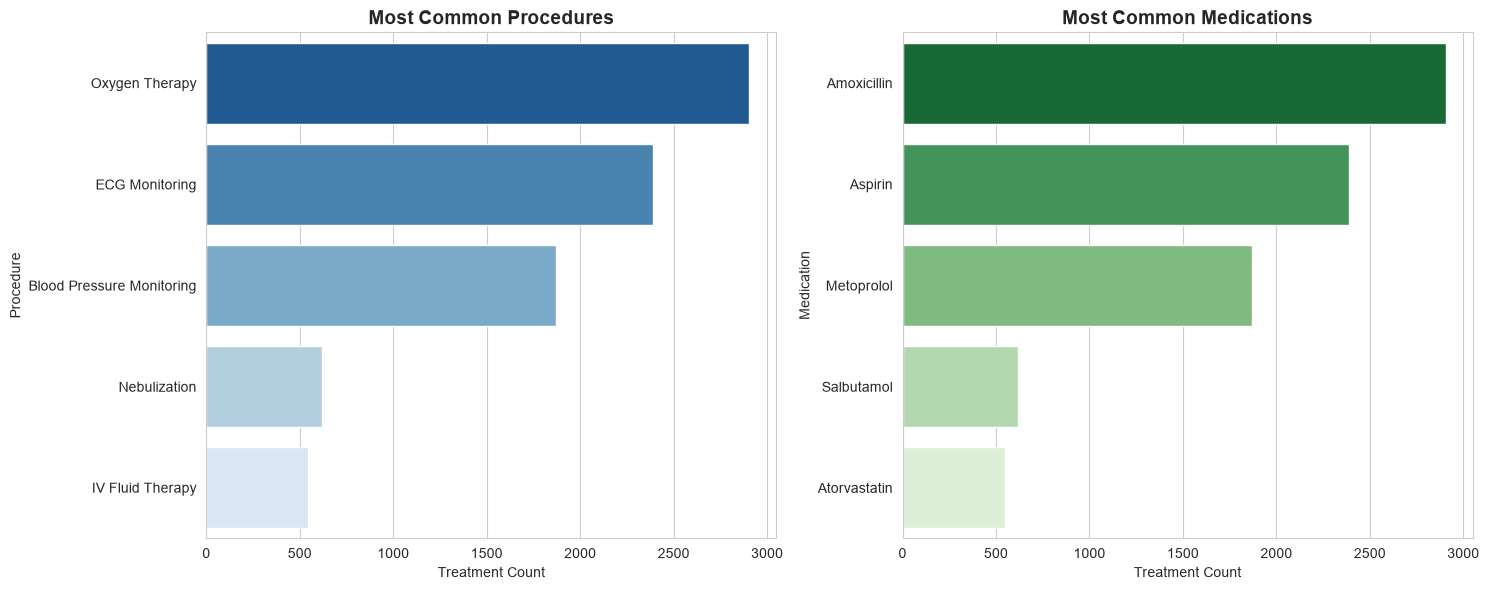

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Procedures
sns.barplot(
    data=procedure_analysis,
    x="Treatment Count",
    y="Procedure",
    hue="Procedure",
    palette="Blues_r",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Most Common Procedures", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Treatment Count")
axes[0].set_ylabel("Procedure")

# Medications
sns.barplot(
    data=medication_analysis,
    x="Treatment Count",
    y="Medication",
    hue="Medication",
    palette="Greens_r",
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Most Common Medications", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Treatment Count")
axes[1].set_ylabel("Medication")

plt.tight_layout()
plt.show()

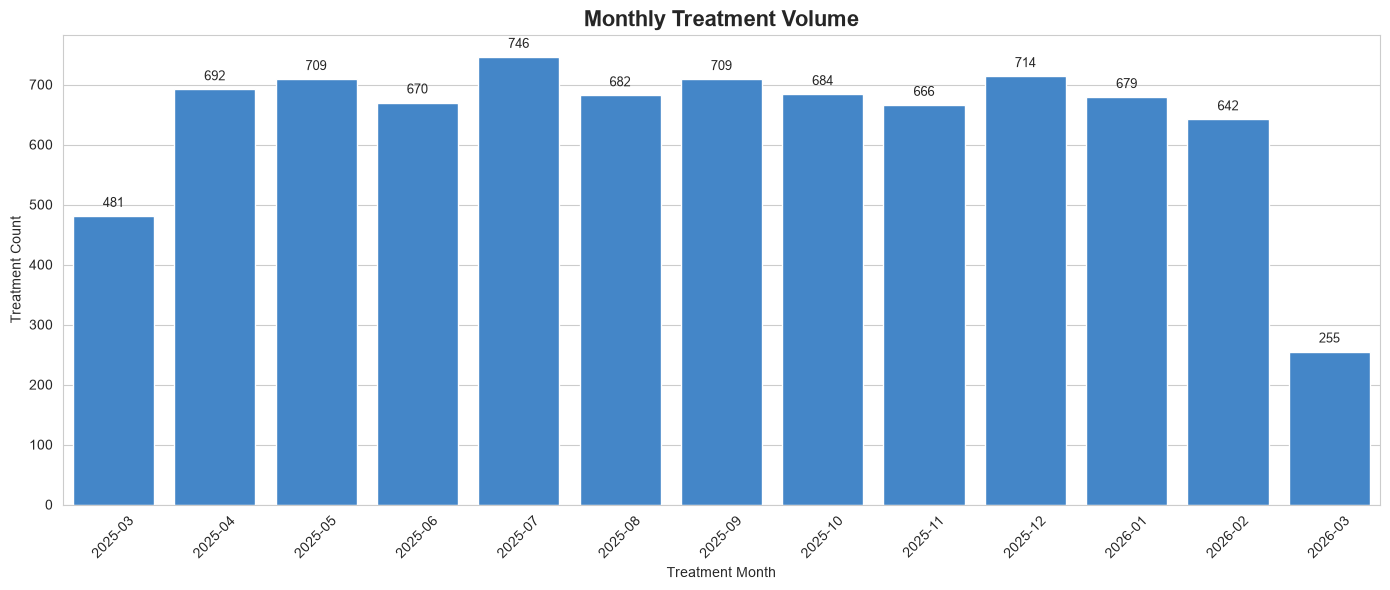

In [46]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=monthly_treatments,
    x="Treatment Month",
    y="Treatment Count",
    color="#2E86DE"
)

plt.title(
    "Monthly Treatment Volume",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Treatment Month")
plt.ylabel("Treatment Count")

plt.xticks(rotation=45)

# Add values above bars
for i, value in enumerate(monthly_treatments["Treatment Count"]):
    plt.text(
        i,
        value + 15,
        str(value),
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [47]:
treatment_count_distribution = (
    treatments.groupby("admission_id")
    .size()
    .value_counts()
    .sort_index()
    .reset_index()
)

treatment_count_distribution.columns = [
    "Treatments per Admission",
    "Admission Count"
]

display(treatment_count_distribution)

,Treatments per Admission,Admission Count
0,1,823
1,2,831
2,3,836
3,4,834


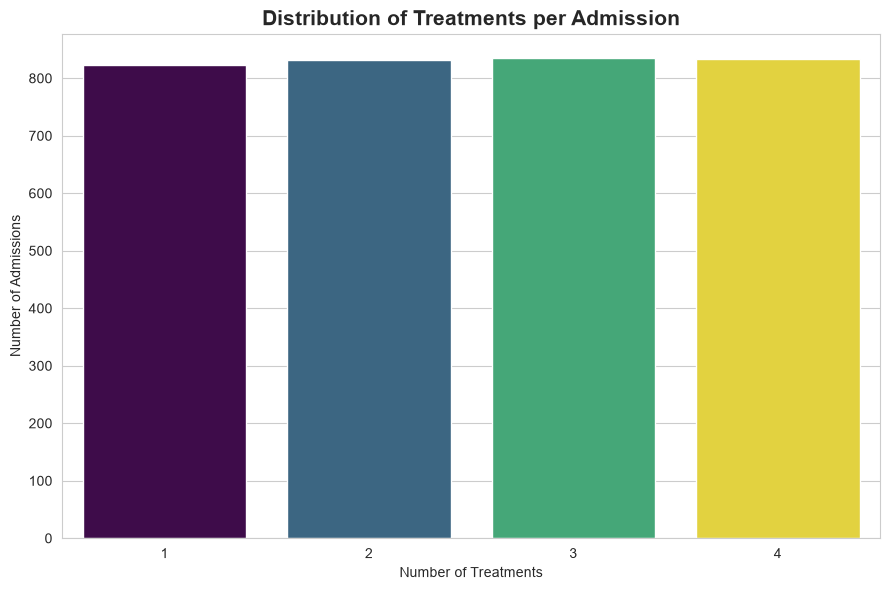

In [48]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=treatment_count_distribution,
    x="Treatments per Admission",
    y="Admission Count",
    hue="Treatments per Admission",
    palette="viridis",
    legend=False
)

plt.title(
    "Distribution of Treatments per Admission",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Number of Treatments")
plt.ylabel("Number of Admissions")

plt.tight_layout()
plt.show()

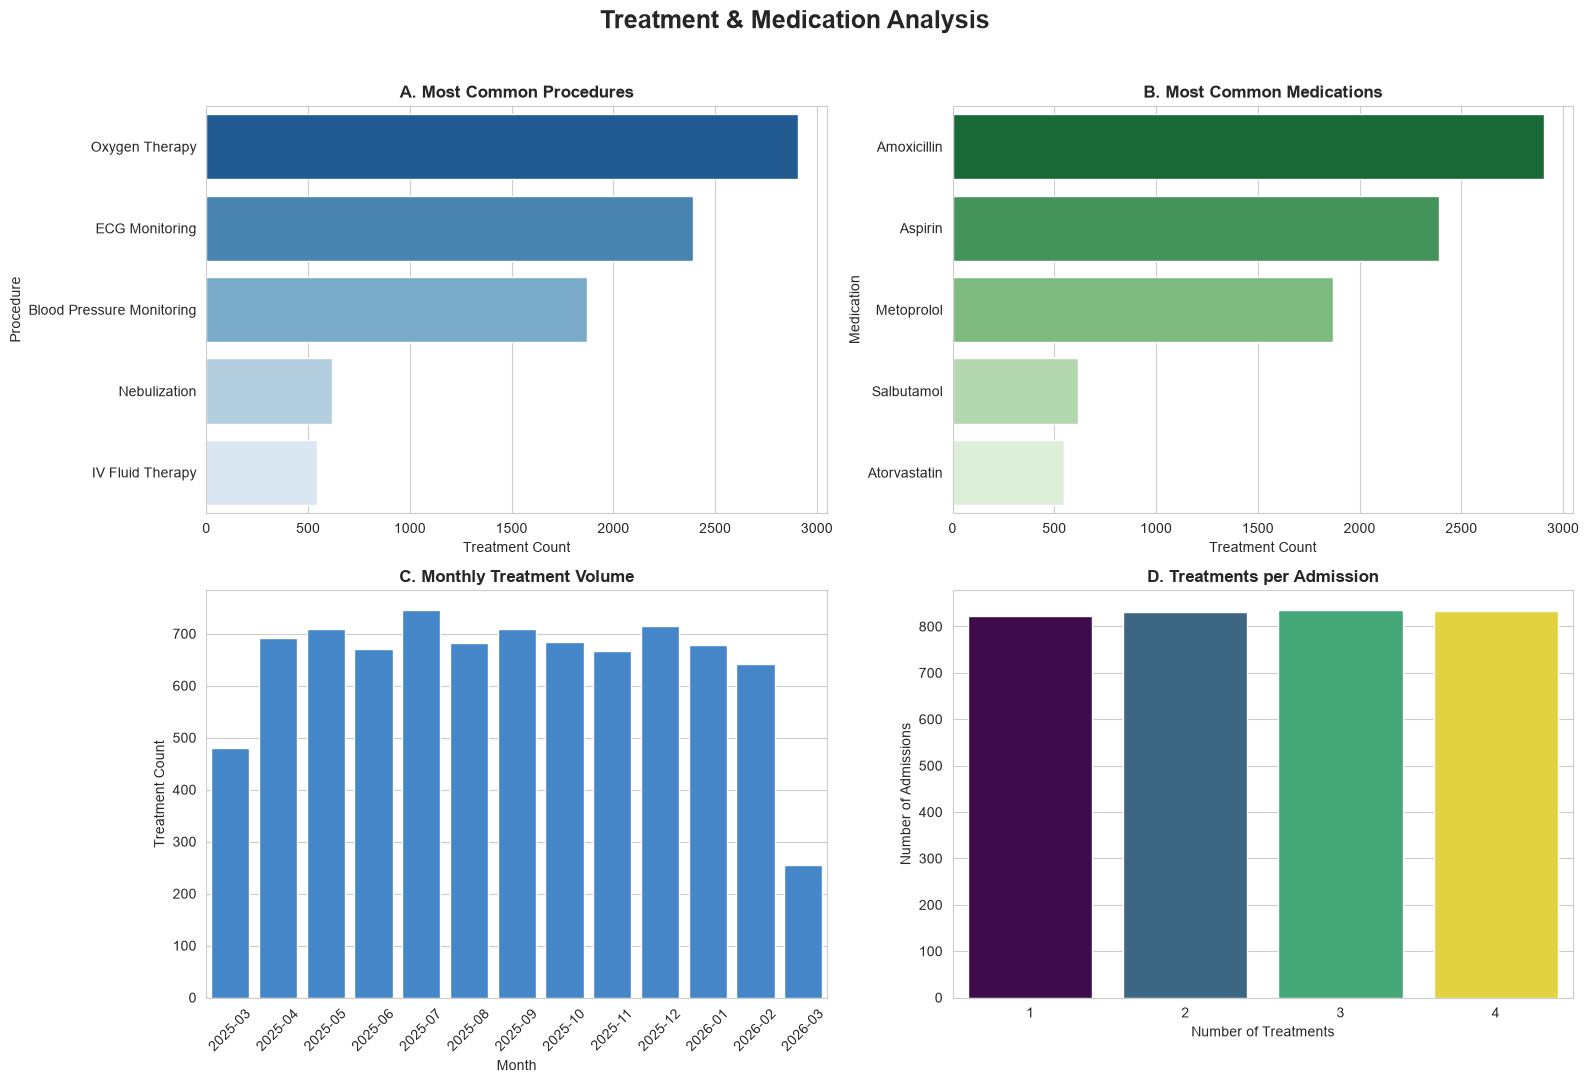

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# -----------------------------
# A. Procedures
# -----------------------------
sns.barplot(
    data=procedure_analysis,
    x="Treatment Count",
    y="Procedure",
    hue="Procedure",
    palette="Blues_r",
    legend=False,
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "A. Most Common Procedures",
    fontweight="bold"
)
axes[0, 0].set_xlabel("Treatment Count")
axes[0, 0].set_ylabel("Procedure")


# -----------------------------
# B. Medications
# -----------------------------
sns.barplot(
    data=medication_analysis,
    x="Treatment Count",
    y="Medication",
    hue="Medication",
    palette="Greens_r",
    legend=False,
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "B. Most Common Medications",
    fontweight="bold"
)
axes[0, 1].set_xlabel("Treatment Count")
axes[0, 1].set_ylabel("Medication")


# -----------------------------
# C. Monthly Treatment Volume
# -----------------------------
sns.barplot(
    data=monthly_treatments,
    x="Treatment Month",
    y="Treatment Count",
    color="#2E86DE",
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "C. Monthly Treatment Volume",
    fontweight="bold"
)
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Treatment Count")
axes[1, 0].tick_params(axis="x", rotation=45)


# -----------------------------
# D. Treatments per Admission
# -----------------------------
sns.barplot(
    data=treatment_count_distribution,
    x="Treatments per Admission",
    y="Admission Count",
    hue="Treatments per Admission",
    palette="viridis",
    legend=False,
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "D. Treatments per Admission",
    fontweight="bold"
)
axes[1, 1].set_xlabel("Number of Treatments")
axes[1, 1].set_ylabel("Number of Admissions")


plt.suptitle(
    "Treatment & Medication Analysis",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Vital Signs Analysis

In [50]:
heart_rate_summary = patients  # temporary line not needed
display(vitals["heart_rate"].describe())

count    33148.000000
mean        89.893719
std         17.603801
min         60.000000
25%         75.000000
50%         90.000000
75%        105.000000
max        120.000000
Name: heart_rate, dtype: float64

In [51]:
vitals["heart_rate_group"] = pd.cut(
    vitals["heart_rate"],
    bins=[0, 59, 99, 120],
    labels=["Below 60", "60-99", "100-120"]
)

heart_rate_analysis = (
    vitals["heart_rate_group"]
    .value_counts()
    .sort_index()
    .reset_index()
)

heart_rate_analysis.columns = [
    "Heart Rate Range",
    "Vital Records"
]

display(heart_rate_analysis)

,Heart Rate Range,Vital Records
0,Below 60,0
1,60-99,21872
2,100-120,11276


In [52]:
display(vitals["oxygen_level"].describe())

count    33148.000000
mean        93.979094
std          3.762773
min         88.000000
25%         91.000000
50%         94.000000
75%         97.000000
max        100.000000
Name: oxygen_level, dtype: float64

In [53]:
vitals["oxygen_group"] = pd.cut(
    vitals["oxygen_level"],
    bins=[0, 89, 94, 100],
    labels=["88-89", "90-94", "95-100"]
)

oxygen_analysis = (
    vitals["oxygen_group"]
    .value_counts()
    .sort_index()
    .reset_index()
)

oxygen_analysis.columns = [
    "Oxygen Level Range",
    "Vital Records"
]

display(oxygen_analysis)

,Oxygen Level Range,Vital Records
0,88-89,5228
1,90-94,12637
2,95-100,15283


In [54]:
display(vitals["temperature"].describe())

count    33148.000000
mean        99.006693
std          1.155410
min         97.000000
25%         98.010000
50%         99.020000
75%        100.000000
max        101.000000
Name: temperature, dtype: float64

In [55]:
vitals["temperature_group"] = pd.cut(
    vitals["temperature"],
    bins=[0, 97.9, 99.4, 101],
    labels=["97.0-97.9", "98.0-99.4", "99.5-101.0"]
)

temperature_analysis = (
    vitals["temperature_group"]
    .value_counts()
    .sort_index()
    .reset_index()
)

temperature_analysis.columns = [
    "Temperature Range",
    "Vital Records"
]

display(temperature_analysis)

,Temperature Range,Vital Records
0,97.0-97.9,7476
1,98.0-99.4,12387
2,99.5-101.0,13285


In [56]:
# Blood pressure
bp_split = vitals["blood_pressure"].str.split("/", expand=True)

vitals["systolic"] = pd.to_numeric(bp_split[0])
vitals["diastolic"] = pd.to_numeric(bp_split[1])

display(
    vitals[["systolic", "diastolic"]].describe()
)

,systolic,diastolic
count,33148.000000,33148.000000
mean,130.120309,82.455231
std,11.848951,7.530400
min,110.000000,70.000000
25%,120.000000,76.000000
50%,130.000000,82.000000
75%,140.000000,89.000000
max,150.000000,95.000000


In [57]:
vitals["bp_category"] = pd.cut(
    vitals["systolic"],
    bins=[0, 119, 129, 139, 200],
    labels=[
        "Below 120",
        "120-129",
        "130-139",
        "140+"
    ]
)

bp_analysis = (
    vitals["bp_category"]
    .value_counts()
    .sort_index()
    .reset_index()
)

bp_analysis.columns = [
    "Systolic BP Range",
    "Vital Records"
]

display(bp_analysis)

,Systolic BP Range,Vital Records
0,Below 120,7998
1,120-129,8045
2,130-139,8023
3,140+,9082


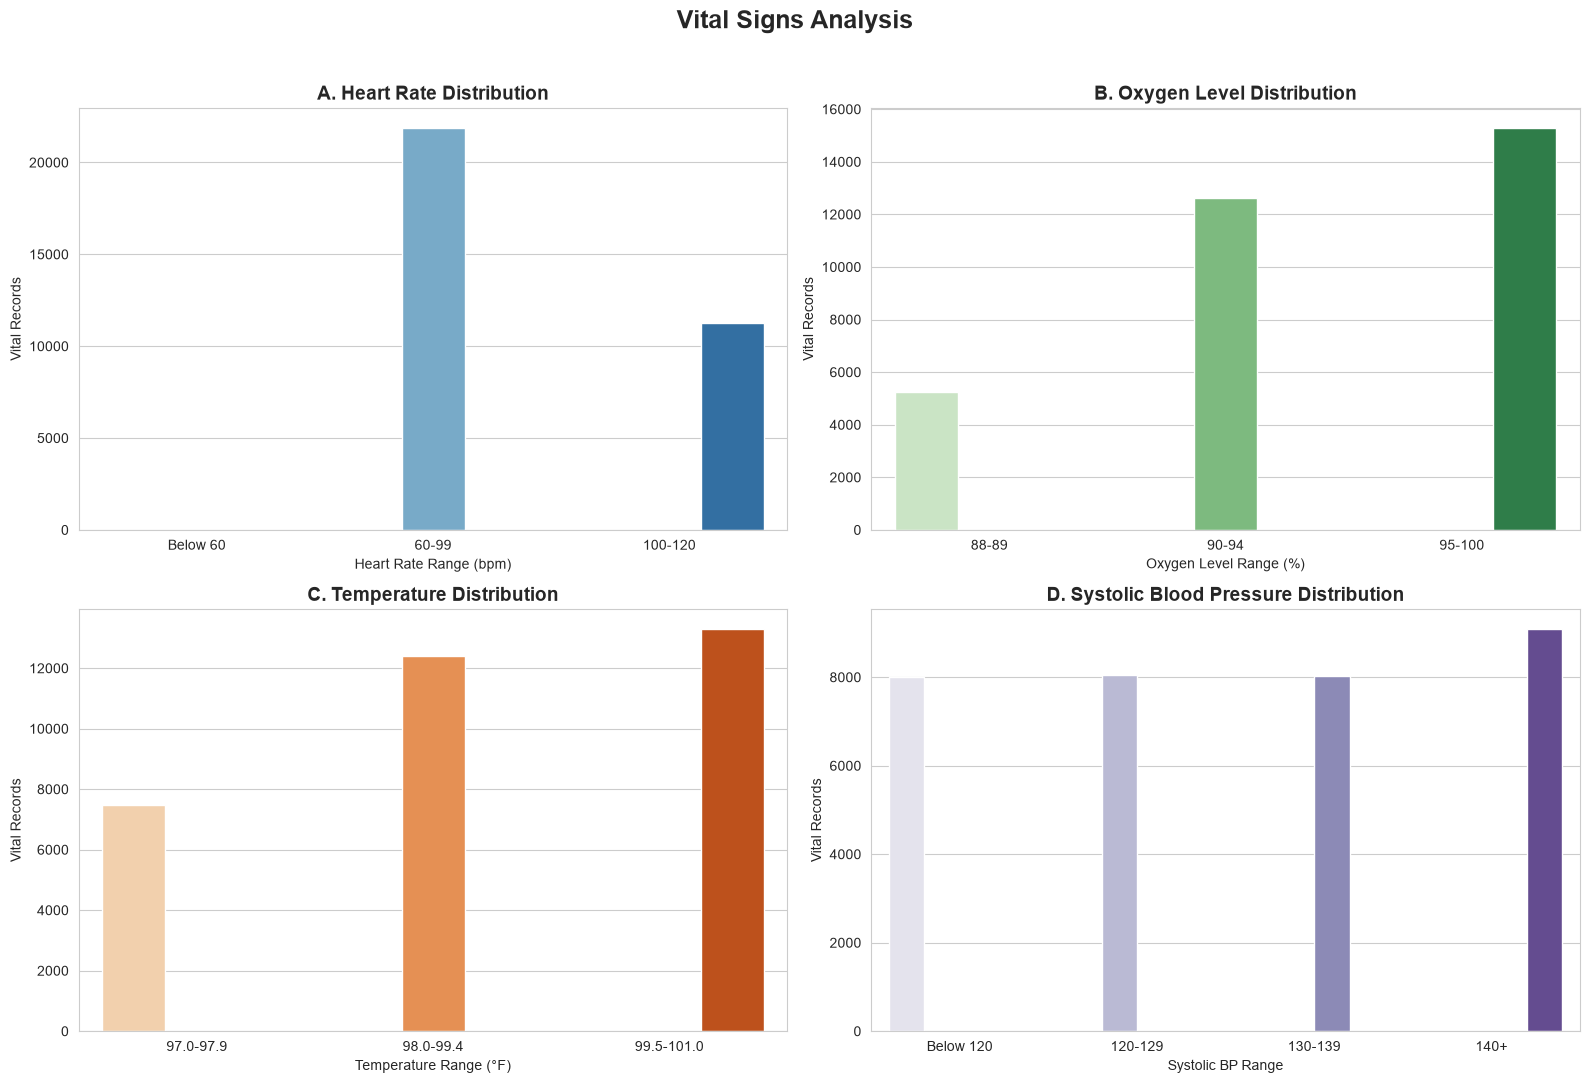

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# --------------------------------
# A. Heart Rate
# --------------------------------
sns.barplot(
    data=heart_rate_analysis,
    x="Heart Rate Range",
    y="Vital Records",
    hue="Heart Rate Range",
    palette="Blues",
    legend=False,
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "A. Heart Rate Distribution",
    fontsize=14,
    fontweight="bold"
)
axes[0, 0].set_xlabel("Heart Rate Range (bpm)")
axes[0, 0].set_ylabel("Vital Records")


# --------------------------------
# B. Oxygen Level
# --------------------------------
sns.barplot(
    data=oxygen_analysis,
    x="Oxygen Level Range",
    y="Vital Records",
    hue="Oxygen Level Range",
    palette="Greens",
    legend=False,
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "B. Oxygen Level Distribution",
    fontsize=14,
    fontweight="bold"
)
axes[0, 1].set_xlabel("Oxygen Level Range (%)")
axes[0, 1].set_ylabel("Vital Records")


# --------------------------------
# C. Temperature
# --------------------------------
sns.barplot(
    data=temperature_analysis,
    x="Temperature Range",
    y="Vital Records",
    hue="Temperature Range",
    palette="Oranges",
    legend=False,
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "C. Temperature Distribution",
    fontsize=14,
    fontweight="bold"
)
axes[1, 0].set_xlabel("Temperature Range (°F)")
axes[1, 0].set_ylabel("Vital Records")


# --------------------------------
# D. Blood Pressure
# --------------------------------
sns.barplot(
    data=bp_analysis,
    x="Systolic BP Range",
    y="Vital Records",
    hue="Systolic BP Range",
    palette="Purples",
    legend=False,
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "D. Systolic Blood Pressure Distribution",
    fontsize=14,
    fontweight="bold"
)
axes[1, 1].set_xlabel("Systolic BP Range")
axes[1, 1].set_ylabel("Vital Records")


plt.suptitle(
    "Vital Signs Analysis",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

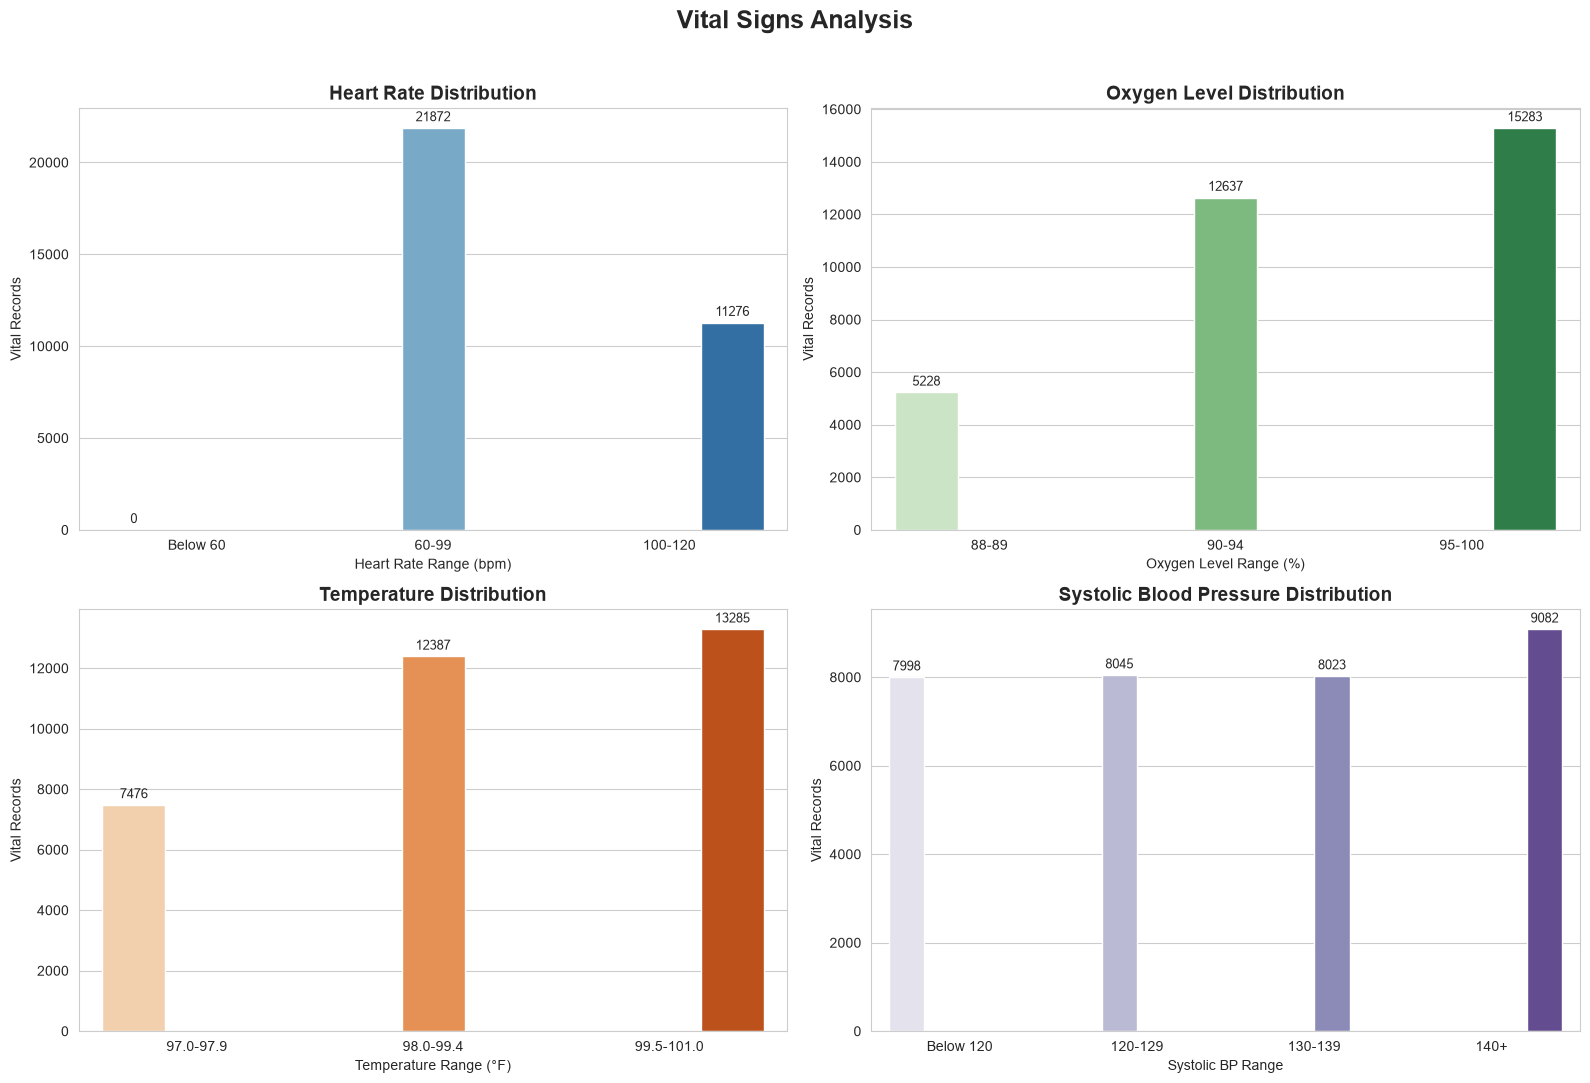

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

charts = [
    (heart_rate_analysis, "Heart Rate Range", "Heart Rate Distribution", "Heart Rate Range (bpm)", "Blues"),
    (oxygen_analysis, "Oxygen Level Range", "Oxygen Level Distribution", "Oxygen Level Range (%)", "Greens"),
    (temperature_analysis, "Temperature Range", "Temperature Distribution", "Temperature Range (°F)", "Oranges"),
    (bp_analysis, "Systolic BP Range", "Systolic Blood Pressure Distribution", "Systolic BP Range", "Purples")
]

for ax, (data, x_col, title, xlabel, palette) in zip(axes.flat, charts):

    sns.barplot(
        data=data,
        x=x_col,
        y="Vital Records",
        hue=x_col,
        palette=palette,
        legend=False,
        ax=ax
    )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Vital Records")

    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=3, fontsize=9)

plt.suptitle(
    "Vital Signs Analysis",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

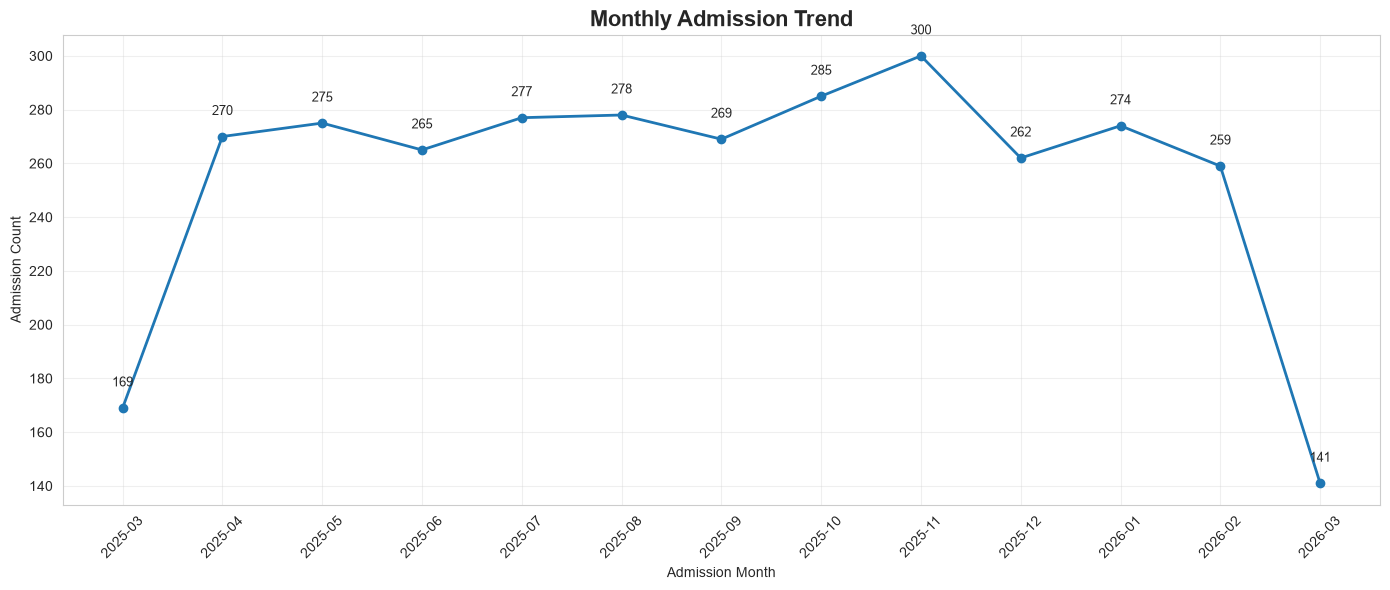

In [60]:
# Again

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_admissions["Admission Month"],
    monthly_admissions["Admission Count"],
    marker="o",
    linewidth=2
)

plt.title(
    "Monthly Admission Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Admission Month")
plt.ylabel("Admission Count")

plt.xticks(rotation=45)

# Add values
for x, y in zip(
    monthly_admissions["Admission Month"],
    monthly_admissions["Admission Count"]
):
    plt.text(
        x,
        y + 8,
        str(y),
        ha="center",
        fontsize=9
    )

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

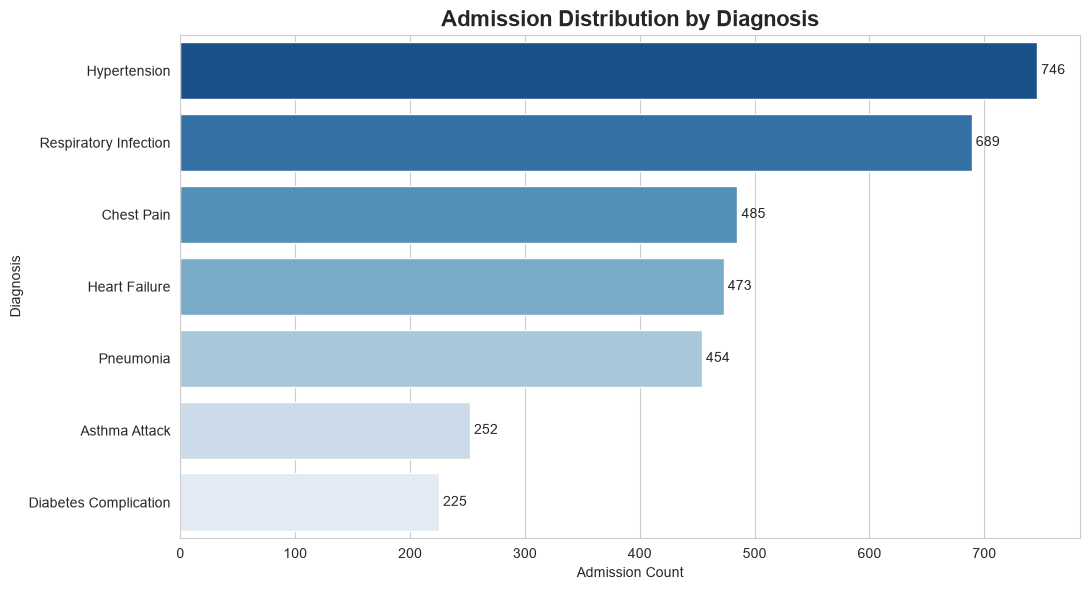

In [61]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=diagnosis_analysis,
    x="Admission Count",
    y="Diagnosis",
    hue="Diagnosis",
    palette="Blues_r",
    legend=False
)

plt.title(
    "Admission Distribution by Diagnosis",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Admission Count")
plt.ylabel("Diagnosis")

for container in plt.gca().containers:
    plt.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

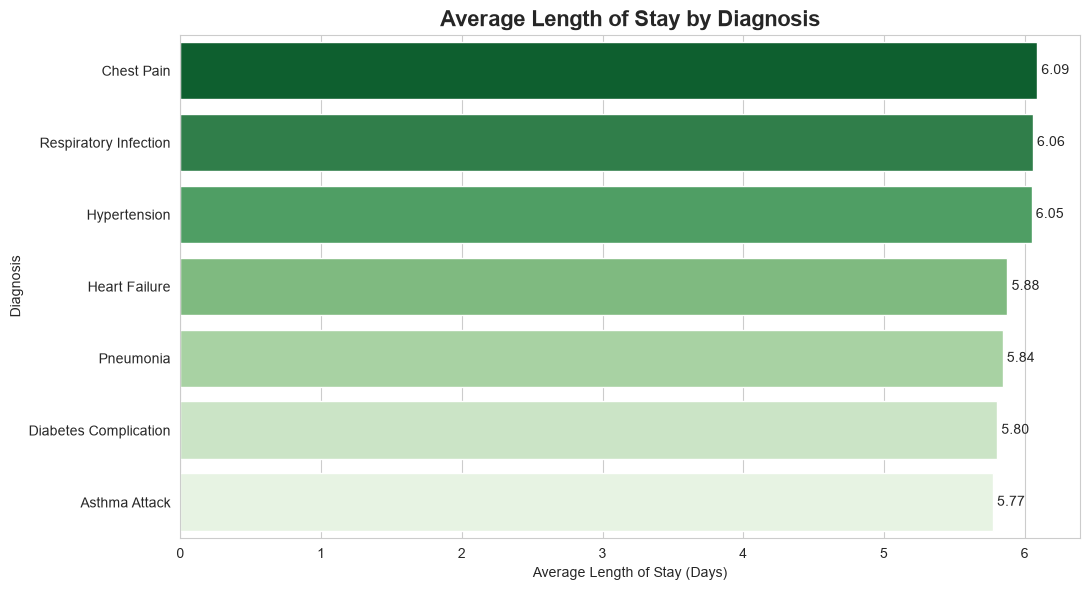

In [62]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=diagnosis_los.sort_values("Average Stay", ascending=False),
    x="Average Stay",
    y="Diagnosis",
    hue="Diagnosis",
    palette="Greens_r",
    legend=False
)

plt.title(
    "Average Length of Stay by Diagnosis",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average Length of Stay (Days)")
plt.ylabel("Diagnosis")

for container in plt.gca().containers:
    plt.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.tight_layout()
plt.show()